# Validação da Apresentação — Analytics PRF 2025

Este notebook valida os números e gera os gráficos utilizados na apresentação **Diagnóstico dos Acidentes Fatais nas Rodovias Federais — PRF 2025**.

**Base:** `dados_abertos_prf-datatran2025.csv` (PRF 2025, acidentes agrupados por ocorrência).

### Regras de cálculo usadas
- **Acidente fatal:** ocorrência com `mortos > 0`.
- **Percentual de acidentes fatais:** `acidentes_fatais / total_acidentes * 100`.
- **Total de vítimas:** `mortos + feridos_graves + feridos_leves`.
- **Taxa de letalidade operacional:** `mortos / total_vitimas * 100`.

> Observação: o PDF da atividade exige que a análise oficial seja feita em Excel/Google Sheets. Este notebook funciona como **validação complementar** dos cálculos e gráficos.

In [1]:
# Bibliotecas
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Localização automática do CSV no repositório
candidatos = [
    Path("../dados/dados_abertos_prf-datatran2025.csv"),
    Path("../../dados/dados_abertos_prf-datatran2025.csv"),
    Path("dados/dados_abertos_prf-datatran2025.csv"),
    Path("dados_abertos_prf-datatran2025.csv"),
    Path("datatran2025.csv"),
]

DATA_PATH = next((p for p in candidatos if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV da PRF não encontrado. Ajuste a lista 'candidatos' para apontar para "
        "dados/dados_abertos_prf-datatran2025.csv."
    )

OUTPUT_DIR = Path("graficos")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding="latin1", sep=";", low_memory=False)

# Colunas auxiliares exigidas pela atividade
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)
df["total_vitimas"] = df["mortos"] + df["feridos_graves"] + df["feridos_leves"]

print(f"Arquivo: {DATA_PATH.resolve()}")
print(f"Linhas: {len(df):,}")
print(f"IDs únicos: {df['id'].nunique():,}")
print(f"Colunas: {len(df.columns)}")


Arquivo: /mnt/data/prf2025/datatran2025.csv
Linhas: 72,529
IDs únicos: 72,529
Colunas: 32


## 1. KPIs globais obrigatórios

A atividade pede os indicadores globais antes dos cruzamentos dimensionais. O notebook calcula todos eles para conferir os valores usados no Excel e na apresentação.

In [3]:
total_acidentes = len(df)
total_acidentes_fatais = int(df["acidente_fatal"].sum())
total_mortos = int(df["mortos"].sum())
total_feridos = int(df["feridos"].sum())
total_vitimas = int(df["total_vitimas"].sum())
percentual_fatais = total_acidentes_fatais / total_acidentes * 100
taxa_letalidade_operacional = total_mortos / total_vitimas * 100

kpis = pd.DataFrame({
    "Indicador": [
        "Total de acidentes",
        "Acidentes fatais",
        "Total de mortos",
        "Total de feridos",
        "Total de vítimas",
        "% de acidentes fatais",
        "Taxa de letalidade operacional"
    ],
    "Valor": [
        total_acidentes,
        total_acidentes_fatais,
        total_mortos,
        total_feridos,
        total_vitimas,
        percentual_fatais,
        taxa_letalidade_operacional
    ]
})

display(kpis)
print(f"\nValidação do slide 3: {total_acidentes:,} acidentes | "
      f"{total_acidentes_fatais:,} acidentes fatais | {percentual_fatais:.2f}% fatais")


,Indicador,Valor
0,Total de acidentes,"72,529.00"
1,Acidentes fatais,"5,210.00"
2,Total de mortos,"6,043.00"
3,Total de feridos,"83,550.00"
4,Total de vítimas,"89,593.00"
5,% de acidentes fatais,7.18
6,Taxa de letalidade operacional,6.74



Validação do slide 3: 72,529 acidentes | 5,210 acidentes fatais | 7.18% fatais


## 2. Slide 4 — Estados críticos

O slide compara Maranhão, Pará e São Paulo com a média nacional. A métrica correta aqui é o **percentual de acidentes fatais por UF**, não a quantidade absoluta de mortes.

,Local,Taxa
0,Maranhão (MA),18.70
1,Pará (PA),17.28
2,Média Nacional,7.18
3,São Paulo (SP),4.38


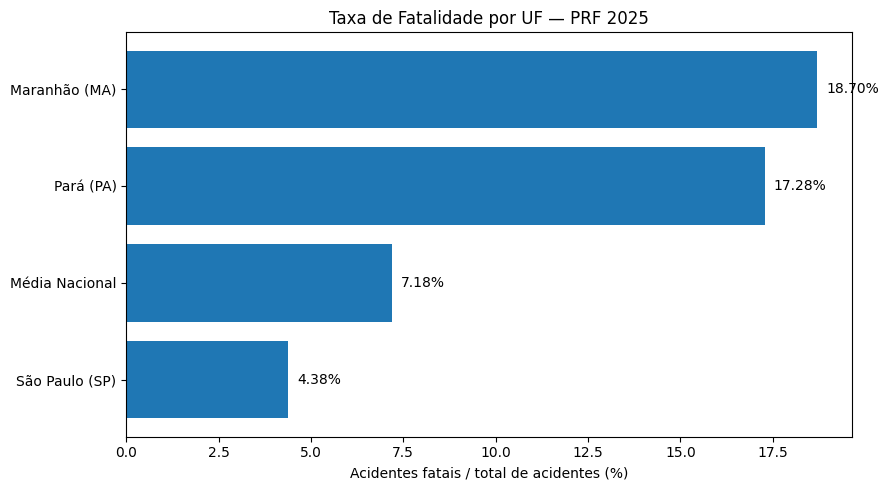

In [4]:
uf = df.groupby("uf").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum")
)
uf["pct_acidentes_fatais"] = uf["acidentes_fatais"] / uf["acidentes"] * 100

slide_uf = pd.DataFrame({
    "Local": ["Maranhão (MA)", "Pará (PA)", "Média Nacional", "São Paulo (SP)"],
    "Taxa": [
        uf.loc["MA", "pct_acidentes_fatais"],
        uf.loc["PA", "pct_acidentes_fatais"],
        percentual_fatais,
        uf.loc["SP", "pct_acidentes_fatais"]
    ]
})

display(slide_uf.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(slide_uf["Local"], slide_uf["Taxa"])
ax.invert_yaxis()
ax.set_title("Taxa de Fatalidade por UF — PRF 2025")
ax.set_xlabel("Acidentes fatais / total de acidentes (%)")
for i, v in enumerate(slide_uf["Taxa"]):
    ax.text(v + 0.25, i, f"{v:.2f}%", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_taxa_fatalidade_uf.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Slide 5 — Tipo de acidente e severidade

Para evitar ambiguidade terminológica, o gráfico abaixo usa **percentual de acidentes fatais por tipo** (`fatais / acidentes`). Isso é diferente da taxa de letalidade operacional (`mortos / vítimas`).

,Tipo,Categoria no CSV,Acidentes,Fatais,% acidentes fatais
0,Colisão Frontal,Colisão frontal,4739,1396,29.46
1,Atropelamento de Pedestre,Atropelamento de Pedestre,3057,902,29.51
2,Capotamento,Capotamento,1373,63,4.59
3,Saída de Pista,Saída de leito carroçável,10209,605,5.93
4,Colisão Traseira,Colisão traseira,14360,619,4.31


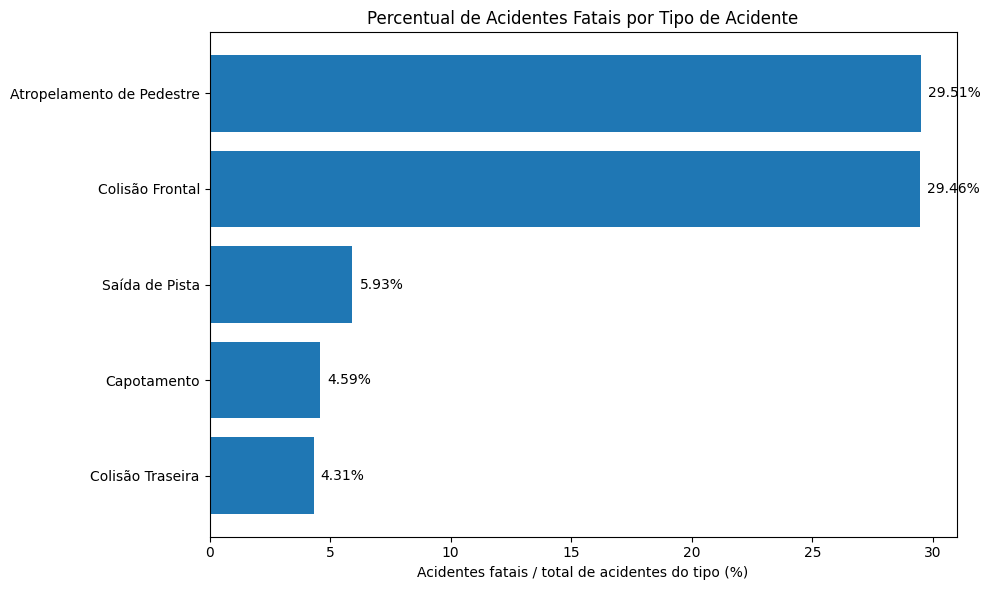

In [5]:
tipo = df.groupby("tipo_acidente").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum"),
    vitimas=("total_vitimas", "sum")
)
tipo["pct_acidentes_fatais"] = tipo["acidentes_fatais"] / tipo["acidentes"] * 100
tipo["letalidade_operacional"] = tipo["mortos"] / tipo["vitimas"] * 100

selecionados = {
    "Colisão Frontal": "Colisão frontal",
    "Atropelamento de Pedestre": "Atropelamento de Pedestre",
    "Capotamento": "Capotamento",
    "Saída de Pista": "Saída de leito carroçável",
    "Colisão Traseira": "Colisão traseira"
}

tipo_slide = pd.DataFrame([
    {
        "Tipo": rotulo,
        "Categoria no CSV": categoria,
        "Acidentes": int(tipo.loc[categoria, "acidentes"]),
        "Fatais": int(tipo.loc[categoria, "acidentes_fatais"]),
        "% acidentes fatais": tipo.loc[categoria, "pct_acidentes_fatais"]
    }
    for rotulo, categoria in selecionados.items()
])

display(tipo_slide.round(2))

plot_tipo = tipo_slide.sort_values("% acidentes fatais")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_tipo["Tipo"], plot_tipo["% acidentes fatais"])
ax.set_title("Percentual de Acidentes Fatais por Tipo de Acidente")
ax.set_xlabel("Acidentes fatais / total de acidentes do tipo (%)")
for i, v in enumerate(plot_tipo["% acidentes fatais"]):
    ax.text(v + 0.3, i, f"{v:.2f}%", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_tipo_acidente_fatalidade.png", dpi=150, bbox_inches="tight")
plt.show()


### Validação do slide 5

Os valores de **Colisão Frontal** e **Atropelamento de Pedestre** ficam próximos de 29%, como apresentado. Já **Capotamento**, **Saída de Pista** e **Colisão Traseira** precisam ser atualizados com os valores calculados acima.

## 4. Slide 6 — Causa-raiz

Os percentuais 41,25%, 30,43% e 29,74% existem na base, mas dois deles foram associados a causas incorretas na apresentação. A célula abaixo identifica as categorias exatas do CSV.

Para preservar a lógica do slide, `Suicídio (presumido)` é excluído do ranking de causas comportamentais/preventivas.

,acidentes,acidentes_fatais,mortos,pct_acidentes_fatais
causa_acidente,,,,
Pedestre andava na pista,606,250,252,41.25
Entrada inopinada do pedestre,667,203,209,30.43
Transitar na contramão,2475,736,961,29.74


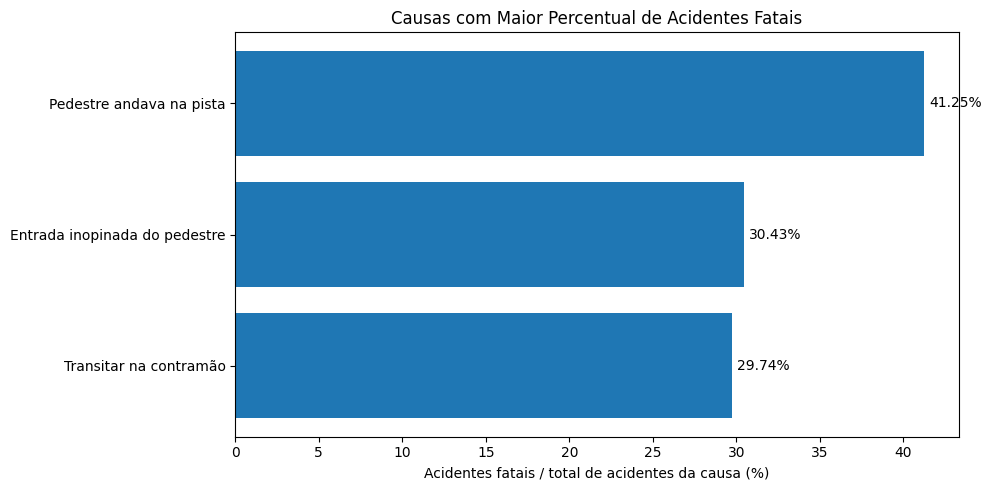

,acidentes,acidentes_fatais,pct_acidentes_fatais
causa_acidente,,,
Ultrapassagem Indevida,1770,302,17.06
Entrada inopinada do pedestre,667,203,30.43
Reação tardia ou ineficiente do condutor,10799,528,4.89
Velocidade Incompatível,4088,385,9.42


In [6]:
causa = df.groupby("causa_acidente").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum")
)
causa["pct_acidentes_fatais"] = causa["acidentes_fatais"] / causa["acidentes"] * 100

ranking_causas = (
    causa.drop(index="Suicídio (presumido)", errors="ignore")
         .sort_values("pct_acidentes_fatais", ascending=False)
         .head(3)
)

display(ranking_causas.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
plot_causa = ranking_causas.sort_values("pct_acidentes_fatais")
ax.barh(plot_causa.index, plot_causa["pct_acidentes_fatais"])
ax.set_title("Causas com Maior Percentual de Acidentes Fatais")
ax.set_xlabel("Acidentes fatais / total de acidentes da causa (%)")
for i, v in enumerate(plot_causa["pct_acidentes_fatais"]):
    ax.text(v + 0.3, i, f"{v:.2f}%", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_causas_maior_fatalidade.png", dpi=150, bbox_inches="tight")
plt.show()

# Checagem das causas escritas no slide atual
causas_slide_atual = [
    "Ultrapassagem Indevida",
    "Entrada inopinada do pedestre",
    "Reação tardia ou ineficiente do condutor",
    "Velocidade Incompatível"
]
display(causa.loc[causas_slide_atual, ["acidentes", "acidentes_fatais", "pct_acidentes_fatais"]].round(2))


**Correção para a apresentação:**
- **41,25%** corresponde a **Pedestre andava na pista**, e não a Ultrapassagem Indevida.
- **30,43%** corresponde a **Entrada inopinada do pedestre**.
- **29,74%** corresponde a **Transitar na contramão**, e não a Reação tardia ou ineficiente do condutor.

O gráfico usa os nomes efetivamente existentes na base da PRF.

## 5. Slide 7 — Fase do dia

Primeiro validamos a taxa por fase do dia. Em seguida, fazemos o cruzamento obrigatório **fase do dia × condição meteorológica** solicitado pela atividade.

,acidentes,acidentes_fatais,pct_acidentes_fatais
fase_dia,,,
Amanhecer,3447,386,11.20
Plena Noite,24781,2522,10.18
Anoitecer,3926,253,6.44
Pleno dia,40375,2049,5.07


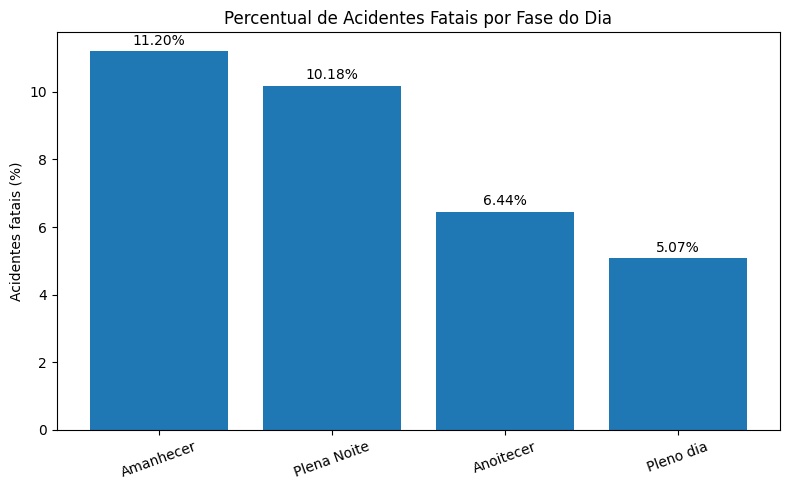

In [7]:
fase = df.groupby("fase_dia").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum")
)
fase["pct_acidentes_fatais"] = fase["acidentes_fatais"] / fase["acidentes"] * 100
fase = fase.sort_values("pct_acidentes_fatais", ascending=False)

display(fase.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fase.index, fase["pct_acidentes_fatais"])
ax.set_title("Percentual de Acidentes Fatais por Fase do Dia")
ax.set_ylabel("Acidentes fatais (%)")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(fase["pct_acidentes_fatais"]):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_fase_dia_fatalidade.png", dpi=150, bbox_inches="tight")
plt.show()


condicao_metereologica,Chuva,Céu Claro,Garoa/Chuvisco,Ignorado,Neve,Nevoeiro/Neblina,Nublado,Sol,Vento
fase_dia,,,,,,,,,
Amanhecer,9.09,11.99,7.14,12.79,NaN,11.24,10.23,14.08,14.29
Anoitecer,5.60,6.88,4.40,8.33,NaN,25.00,5.53,6.45,0.00
Plena Noite,7.93,10.49,8.10,10.90,0.00,15.10,10.34,10.00,8.45
Pleno dia,4.92,5.15,3.88,5.00,NaN,1.53,4.63,5.72,15.38


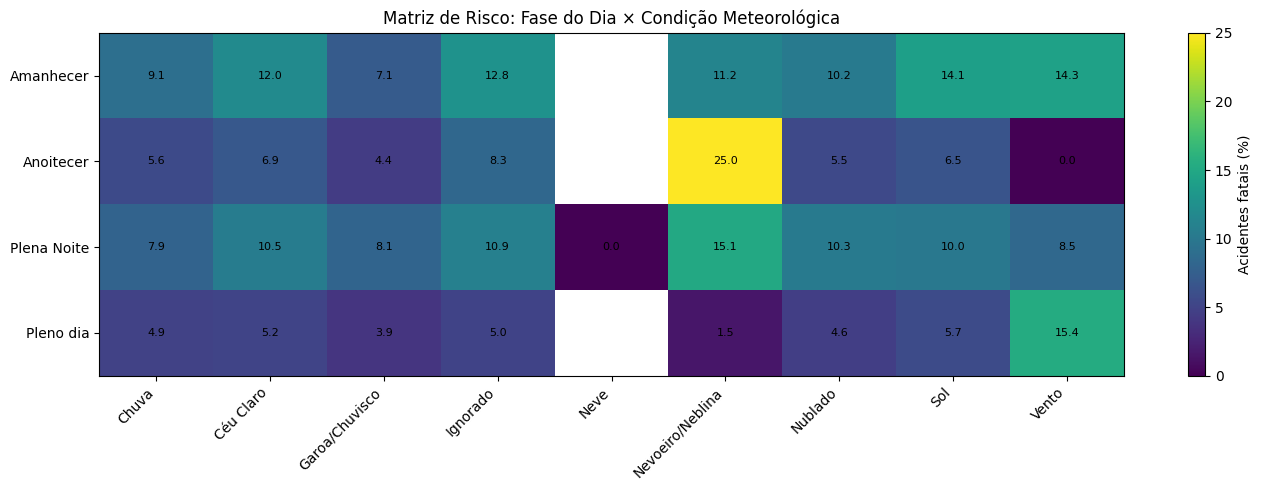

In [8]:
# Matriz obrigatória: fase do dia x condição meteorológica
env = df.groupby(["fase_dia", "condicao_metereologica"]).agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum")
).reset_index()
env["pct_acidentes_fatais"] = env["acidentes_fatais"] / env["acidentes"] * 100

matriz_env = env.pivot(
    index="fase_dia",
    columns="condicao_metereologica",
    values="pct_acidentes_fatais"
)

display(matriz_env.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matriz_env.values, aspect="auto")
fig.colorbar(im, ax=ax, label="Acidentes fatais (%)")
ax.set_xticks(range(len(matriz_env.columns)))
ax.set_xticklabels(matriz_env.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz_env.index)))
ax.set_yticklabels(matriz_env.index)
ax.set_title("Matriz de Risco: Fase do Dia × Condição Meteorológica")

for i in range(matriz_env.shape[0]):
    for j in range(matriz_env.shape[1]):
        valor = matriz_env.iloc[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.1f}", ha="center", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_matriz_fase_clima.png", dpi=150, bbox_inches="tight")
plt.show()


### Observação sobre clima

A base não sustenta uma afirmação genérica de que **chuva** aumenta a fatalidade em qualquer período. **Nevoeiro/neblina** apresenta taxa global elevada, mas chuva deve ser analisada no cruzamento com fase do dia e com o volume de ocorrências. Evite concluir causalidade apenas pela porcentagem.

## 6. Slide 8 — Padrão semanal

,acidentes,acidentes_fatais,pct_acidentes_fatais
dia_semana,,,
domingo,11470,1017,8.87
sábado,11554,953,8.25
sexta-feira,11197,766,6.84
quinta-feira,9405,625,6.65
terça-feira,9062,586,6.47
segunda-feira,10285,655,6.37
quarta-feira,9556,608,6.36


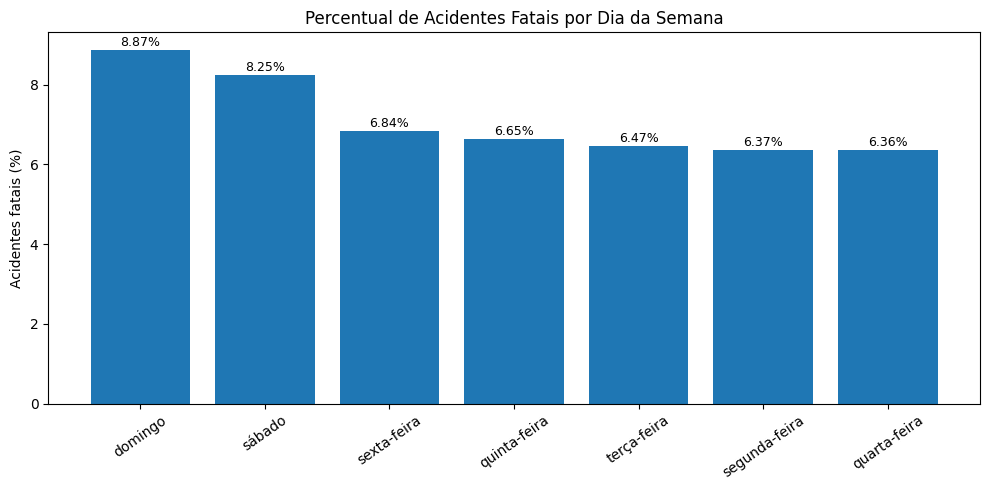

In [9]:
dia = df.groupby("dia_semana").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum")
)
dia["pct_acidentes_fatais"] = dia["acidentes_fatais"] / dia["acidentes"] * 100
dia = dia.sort_values("pct_acidentes_fatais", ascending=False)

display(dia.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dia.index, dia["pct_acidentes_fatais"])
ax.set_title("Percentual de Acidentes Fatais por Dia da Semana")
ax.set_ylabel("Acidentes fatais (%)")
ax.tick_params(axis="x", rotation=35)
for i, v in enumerate(dia["pct_acidentes_fatais"]):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_dia_semana_fatalidade.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Slide 9 — Sentido da via e mortes

,acidentes,acidentes_fatais,mortos
sentido_via,,,
Crescente,38715,2907,3408
Decrescente,33647,2303,2635


Diferença de mortos: 773
Crescente possui 29.34% mais mortos que Decrescente.


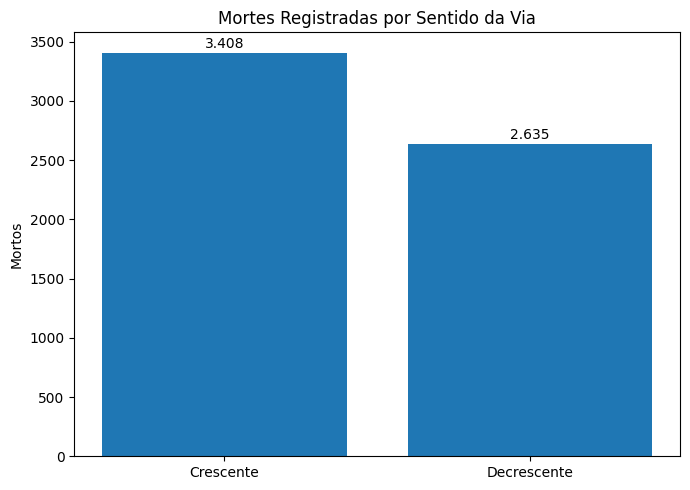

In [10]:
sentido = df.groupby("sentido_via").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum")
)

sentido_plot = sentido.loc[["Crescente", "Decrescente"]].copy()
display(sentido_plot)

diferenca = int(sentido_plot.loc["Crescente", "mortos"] - sentido_plot.loc["Decrescente", "mortos"])
assimetria_relativa = diferenca / sentido_plot.loc["Decrescente", "mortos"] * 100
print(f"Diferença de mortos: {diferenca:,}")
print(f"Crescente possui {assimetria_relativa:.2f}% mais mortos que Decrescente.")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(sentido_plot.index, sentido_plot["mortos"])
ax.set_title("Mortes Registradas por Sentido da Via")
ax.set_ylabel("Mortos")
for i, v in enumerate(sentido_plot["mortos"]):
    ax.text(i, v + 40, f"{int(v):,}".replace(",", "."), ha="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_sentido_via_mortos.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Complemento exigido pela atividade — BR e municípios

A apresentação atual enfatiza UFs, mas o roteiro da atividade pede **UF, BR e Municípios**, além da matriz **UF × BR**. Os gráficos abaixo cobrem essa lacuna e podem ser usados para revisar o slide espacial.

,acidentes,acidentes_fatais,mortos,pct_acidentes_fatais
BR-101,13014,682,760,5.24
BR-116,11021,638,708,5.79
BR-153,2789,226,282,8.10
BR-40,3502,180,214,5.14
BR-163,2519,173,210,6.87


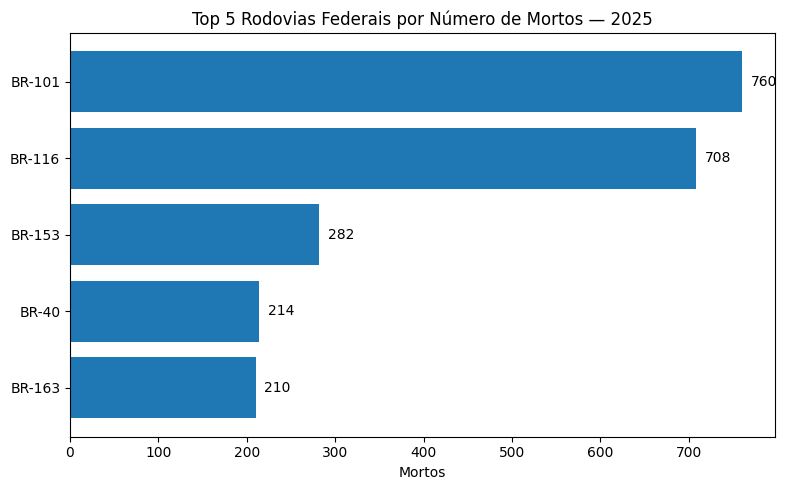

In [11]:
# Top 5 BRs por número de mortos
br = df.groupby("br").agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum")
)
br["pct_acidentes_fatais"] = br["acidentes_fatais"] / br["acidentes"] * 100
br_top5 = br.sort_values("mortos", ascending=False).head(5).copy()
br_top5.index = [f"BR-{int(x)}" for x in br_top5.index]

display(br_top5.round(2))

plot_br = br_top5.sort_values("mortos")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_br.index, plot_br["mortos"])
ax.set_title("Top 5 Rodovias Federais por Número de Mortos — 2025")
ax.set_xlabel("Mortos")
for i, v in enumerate(plot_br["mortos"]):
    ax.text(v + 10, i, f"{int(v)}", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_top5_br_mortos.png", dpi=150, bbox_inches="tight")
plt.show()


local  acidentes  \
uf municipio                                                      
DF BRASILIA                            BRASILIA (DF)       1011   
BA FEIRA DE SANTANA            FEIRA DE SANTANA (BA)        403   
PR SAO JOSE DOS PINHAIS    SAO JOSE DOS PINHAIS (PR)        464   
   CURITIBA                            CURITIBA (PR)        702   
RJ CAMPOS DOS GOYTACAZES  CAMPOS DOS GOYTACAZES (RJ)        350   
   DUQUE DE CAXIAS              DUQUE DE CAXIAS (RJ)        847   
MS CAMPO GRANDE                    CAMPO GRANDE (MS)        310   
PE RECIFE                                RECIFE (PE)        615   
PI TERESINA                            TERESINA (PI)        499   
SP SAO PAULO                          SAO PAULO (SP)        316   

                          acidentes_fatais  mortos  pct_acidentes_fatais  
uf municipio                                                              
DF BRASILIA                             43      47                  4.25  
BA FEIRA DE SANTANA                     28      31                  6.95  
PR SAO JOSE DOS PINHAIS                 28      30                  6.03  
   CURITIBA                             29      29                  4.13  
RJ CAMPOS DOS GOYTACAZES                27      28                  7.71  
   DUQUE DE CAXIAS                      27      27                  3.19  
MS CAMPO GRANDE                         23      27                  7.42  
PE RECIFE                               25      26                  4.07  
PI TERESINA                             23      24                  4.61  
SP SAO PAULO                            23      23                  7.28

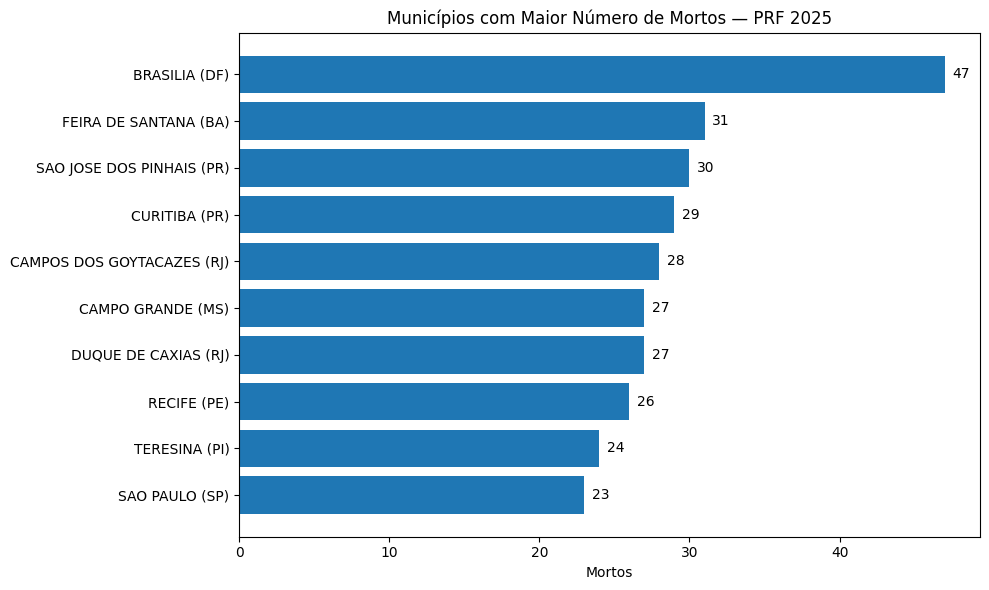

In [12]:
# Municípios com maior número de mortos
municipio = df.groupby(["uf", "municipio"]).agg(
    acidentes=("id", "count"),
    acidentes_fatais=("acidente_fatal", "sum"),
    mortos=("mortos", "sum"),
    feridos_graves=("feridos_graves", "sum")
)
municipio["pct_acidentes_fatais"] = municipio["acidentes_fatais"] / municipio["acidentes"] * 100
mun_top10 = municipio.sort_values("mortos", ascending=False).head(10).copy()
mun_top10["local"] = [f"{mun} ({uf})" for uf, mun in mun_top10.index]

display(mun_top10[["local", "acidentes", "acidentes_fatais", "mortos", "pct_acidentes_fatais"]].round(2))

plot_mun = mun_top10.sort_values("mortos")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_mun["local"], plot_mun["mortos"])
ax.set_title("Municípios com Maior Número de Mortos — PRF 2025")
ax.set_xlabel("Mortos")
for i, v in enumerate(plot_mun["mortos"]):
    ax.text(v + 0.5, i, f"{int(v)}", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_top10_municipios_mortos.png", dpi=150, bbox_inches="tight")
plt.show()


,BR-40,BR-101,BR-116,BR-153,BR-163,BR-262,BR-277,BR-364,BR-376,BR-381
uf,,,,,,,,,,
AC,0,0,0,0,0,0,0,220,0,0
AL,0,254,0,0,0,0,0,0,0,0
BA,0,956,1038,0,0,0,0,0,0,0
CE,0,0,707,0,0,0,0,0,0,0
DF,124,0,0,0,0,0,0,0,0,0
ES,0,2084,0,0,0,382,0,0,0,0
GO,335,0,0,973,0,0,0,137,0,0
MG,1972,0,1412,269,0,1095,0,45,0,2845
MS,0,0,0,0,781,285,0,0,62,0


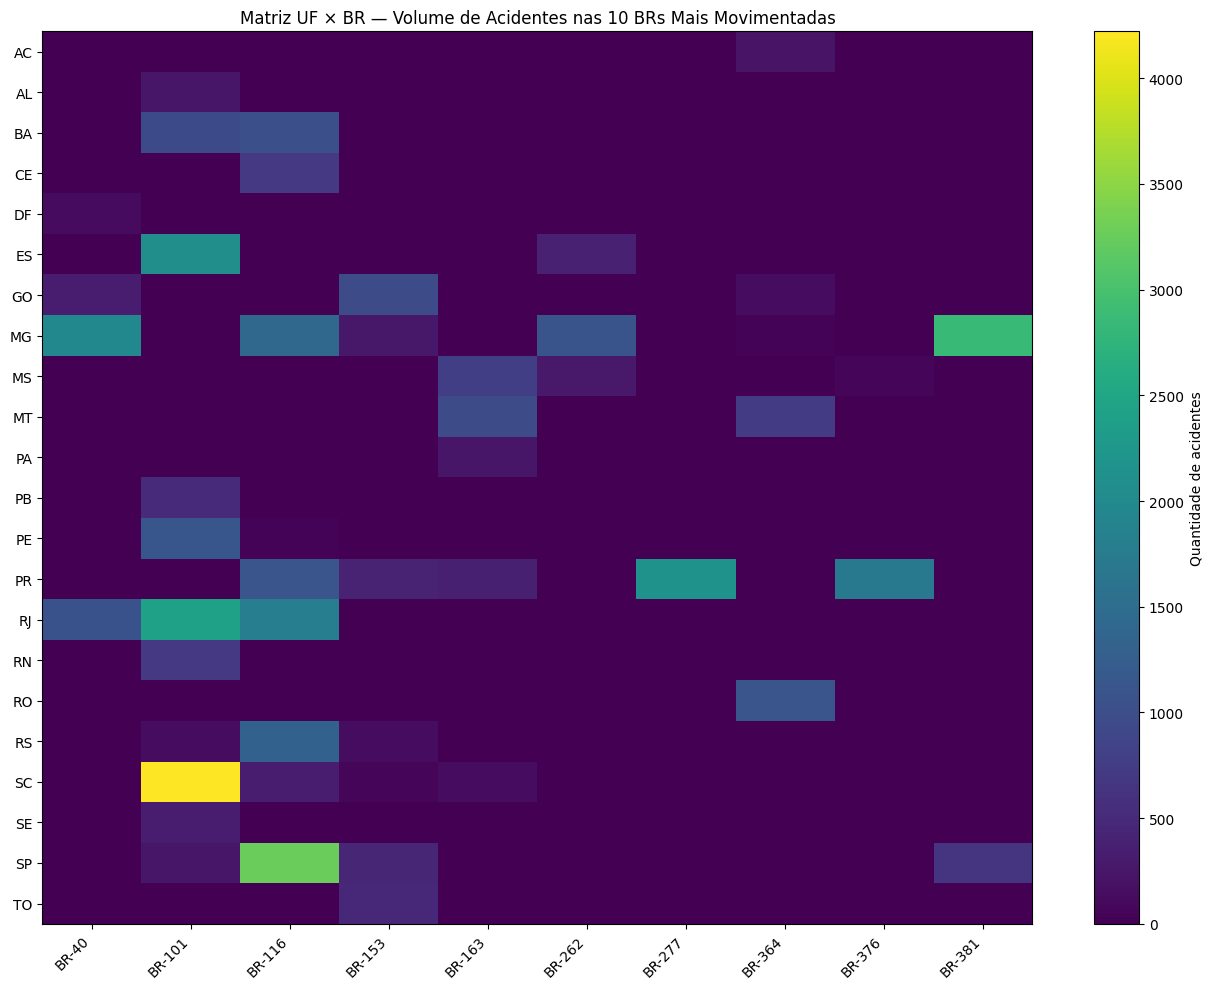

In [13]:
# Matriz UF x BR por volume de acidentes (10 BRs com maior volume nacional)
top_brs_volume = df["br"].value_counts().head(10).index
matriz_uf_br = pd.pivot_table(
    df[df["br"].isin(top_brs_volume)],
    index="uf",
    columns="br",
    values="id",
    aggfunc="count",
    fill_value=0
)
matriz_uf_br.columns = [f"BR-{int(x)}" for x in matriz_uf_br.columns]

display(matriz_uf_br)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(matriz_uf_br.values, aspect="auto")
fig.colorbar(im, ax=ax, label="Quantidade de acidentes")
ax.set_xticks(range(len(matriz_uf_br.columns)))
ax.set_xticklabels(matriz_uf_br.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz_uf_br.index)))
ax.set_yticklabels(matriz_uf_br.index)
ax.set_title("Matriz UF × BR — Volume de Acidentes nas 10 BRs Mais Movimentadas")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_matriz_uf_br_volume.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Quadro de validação da apresentação

Resumo das principais divergências encontradas entre os slides e os dados do CSV.

In [14]:
# Comparação objetiva entre valores da apresentação e valores calculados
checks = pd.DataFrame([
    [3, "Total de acidentes", 72529, total_acidentes],
    [3, "Acidentes fatais", 5210, total_acidentes_fatais],
    [3, "% acidentes fatais", 7.18, percentual_fatais],
    [4, "MA - % acidentes fatais", 18.70, uf.loc["MA", "pct_acidentes_fatais"]],
    [4, "PA - % acidentes fatais", 17.30, uf.loc["PA", "pct_acidentes_fatais"]],
    [4, "SP - % acidentes fatais", 4.38, uf.loc["SP", "pct_acidentes_fatais"]],
    [5, "Colisão frontal", 29.00, tipo.loc["Colisão frontal", "pct_acidentes_fatais"]],
    [5, "Atropelamento de Pedestre", 29.00, tipo.loc["Atropelamento de Pedestre", "pct_acidentes_fatais"]],
    [5, "Capotamento", 12.00, tipo.loc["Capotamento", "pct_acidentes_fatais"]],
    [5, "Saída de Pista", 9.00, tipo.loc["Saída de leito carroçável", "pct_acidentes_fatais"]],
    [5, "Colisão traseira", 2.80, tipo.loc["Colisão traseira", "pct_acidentes_fatais"]],
    [6, "Ultrapassagem Indevida", 41.25, causa.loc["Ultrapassagem Indevida", "pct_acidentes_fatais"]],
    [6, "Entrada inopinada do pedestre", 30.43, causa.loc["Entrada inopinada do pedestre", "pct_acidentes_fatais"]],
    [6, "Reação tardia do condutor", 29.74, causa.loc["Reação tardia ou ineficiente do condutor", "pct_acidentes_fatais"]],
    [7, "Amanhecer", 11.00, fase.loc["Amanhecer", "pct_acidentes_fatais"]],
    [7, "Plena Noite", 10.00, fase.loc["Plena Noite", "pct_acidentes_fatais"]],
    [7, "Anoitecer", 7.00, fase.loc["Anoitecer", "pct_acidentes_fatais"]],
    [7, "Pleno dia", 5.00, fase.loc["Pleno dia", "pct_acidentes_fatais"]],
    [8, "Domingo", 9.00, dia.loc["domingo", "pct_acidentes_fatais"]],
    [8, "Sábado", 8.20, dia.loc["sábado", "pct_acidentes_fatais"]],
    [8, "Sexta-feira", 7.50, dia.loc["sexta-feira", "pct_acidentes_fatais"]],
    [8, "Segunda-feira", 6.80, dia.loc["segunda-feira", "pct_acidentes_fatais"]],
    [8, "Quarta-feira", 6.50, dia.loc["quarta-feira", "pct_acidentes_fatais"]],
    [8, "Terça-feira", 6.30, dia.loc["terça-feira", "pct_acidentes_fatais"]],
    [8, "Quinta-feira", 6.10, dia.loc["quinta-feira", "pct_acidentes_fatais"]],
    [9, "Mortos - sentido crescente", 2572, sentido.loc["Crescente", "mortos"]],
    [9, "Mortos - sentido decrescente", 1937, sentido.loc["Decrescente", "mortos"]],
], columns=["Slide", "Indicador", "Apresentação", "Calculado"])

checks["Diferença"] = checks["Calculado"] - checks["Apresentação"]
checks["Status"] = np.where(
    np.isclose(checks["Apresentação"], checks["Calculado"], rtol=0, atol=0.55),
    "OK / arredondamento",
    "REVISAR"
)

display(checks.round(2))

,Slide,Indicador,Apresentação,Calculado,Diferença,Status
0,3,Total de acidentes,"72,529.00","72,529.00",0.00,OK / arredondamento
1,3,Acidentes fatais,"5,210.00","5,210.00",0.00,OK / arredondamento
2,3,% acidentes fatais,7.18,7.18,0.00,OK / arredondamento
3,4,MA - % acidentes fatais,18.70,18.70,0.00,OK / arredondamento
4,4,PA - % acidentes fatais,17.30,17.28,-0.02,OK / arredondamento
5,4,SP - % acidentes fatais,4.38,4.38,-0.00,OK / arredondamento
6,5,Colisão frontal,29.00,29.46,0.46,OK / arredondamento
7,5,Atropelamento de Pedestre,29.00,29.51,0.51,OK / arredondamento
8,5,Capotamento,12.00,4.59,-7.41,REVISAR
9,5,Saída de Pista,9.00,5.93,-3.07,REVISAR


## 10. Conclusões para a entrega

1. Os **KPIs globais principais do slide 3** (72.529 acidentes, 5.210 acidentes fatais e 7,18%) estão corretos para este CSV.
2. O **slide 4** está numericamente consistente para MA, PA e SP, mas a atividade pede também BR e municípios.
3. O **slide 5** precisa corrigir Capotamento, Saída de Pista e Colisão Traseira.
4. O **slide 6** contém percentuais reais, porém dois percentuais estão ligados às causas erradas. Use os nomes exatos do CSV.
5. O **slide 7** está próximo dos dados por fase do dia, mas a atividade exige também o cruzamento com condição meteorológica.
6. O **slide 8** deve ser atualizado com os percentuais calculados diretamente da base.
7. O **slide 9** precisa ser corrigido: a soma de mortos por sentido no CSV não coincide com os números atuais da apresentação.
8. A pasta `graficos/` é criada automaticamente e contém os PNGs gerados para conferência e possível uso na apresentação.
